Availability Matrix:  alphaF-25sl-7cb-3ft
Availability Matrix:  alphaF-35sl-6cb-3ft
Availability Matrix:  alphaF-45sl-7cb-3ft
Availability Matrix:  alphaF-50sl-5cb-3ft
Availability Matrix:  alphaF-55sl-6cb-3ft
Availability Matrix:  alphaF-65sl-4cb-3ft
Availability Matrix:  alphaF-65sl-7cb-3ft
Availability Matrix:  alphaF-70sl-5cb-3ft
Availability Matrix:  alphaF-75sl-6cb-3ft
Availability Matrix:  alphaF-80sl-3cb-3ft
Availability Matrix:  alphaF-85sl-4cb-3ft
Availability Matrix:  alphaF-90sl-5cb-3ft
Availability Matrix:  alphaF-95sl-2cb-3ft
Availability Matrix:  alphaF-95sl-6cb-3ft
Availability Matrix:  alphaF-100sl-3cb-3ft
Availability Matrix:  alphaF-105sl-4cb-3ft
Availability Matrix:  alphaF-110sl-1cb-3ft
Availability Matrix:  alphaF-110sl-5cb-3ft
Availability Matrix:  alphaF-115sl-2cb-3ft
Availability Matrix:  alphaF-115sl-6cb-3ft
Availability Matrix:  alphaF-125sl-4cb-3ft
Availability Matrix:  alphaF-130sl-1cb-3ft
Availability Matrix:  alphaF-130sl-5cb-3ft
Availability Matrix:  alp

,algorithm,availability,alpha,participation,max_test_accuracy,final_test_accuracy,test_accuracy,seed,lr,event,n_clients,biased
0,fedavg,alphaF-25sl-7cb-3ft,0.5,known,57.810003,57.810003,"[0.10589999705553055, 0.22699999809265137, 0.1...",42,1e-2,global,7,2
1,fedavg,alphaF-35sl-6cb-3ft,0.5,known,64.469999,63.980001,"[0.10589999705553055, 0.20110000669956207, 0.3...",42,1e-2,global,7,2
2,fedavg,alphaF-45sl-7cb-3ft,0.5,known,54.530001,54.530001,"[0.10589999705553055, 0.15080000460147858, 0.2...",42,1e-2,global,7,2
3,fedavg,alphaF-50sl-5cb-3ft,0.5,known,66.329998,66.329998,"[0.10599999874830246, 0.20190000534057617, 0.2...",42,1e-2,global,7,2
4,fedavg,alphaF-55sl-6cb-3ft,0.5,known,67.339998,67.339998,"[0.10589999705553055, 0.21699999272823334, 0.2...",42,1e-2,global,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...
193,fedavg,alphaF-175sl-2cb-3ft,0.5,known,75.120002,75.120002,"[0.10350000113248825, 0.26980000734329224, 0.3...",84,5e-2,global,7,2
194,fedavg,alphaF-120sl-3cb-3ft,0.5,known,74.890000,74.620003,"[0.10350000113248825, 0.21240000426769257, 0.3...",84,5e-2,global,7,2
195,fedavg,alphaF-140sl-3cb-3ft,0.5,known,74.559999,74.559999,"[0.10360000282526016, 0.20739999413490295, 0.3...",84,5e-2,global,7,2
196,fedavg,alphaF-160sl-3cb-3ft,0.5,known,75.129998,75.040001,"[0.10360000282526016, 0.20679999887943268, 0.3...",84,5e-2,global,7,2


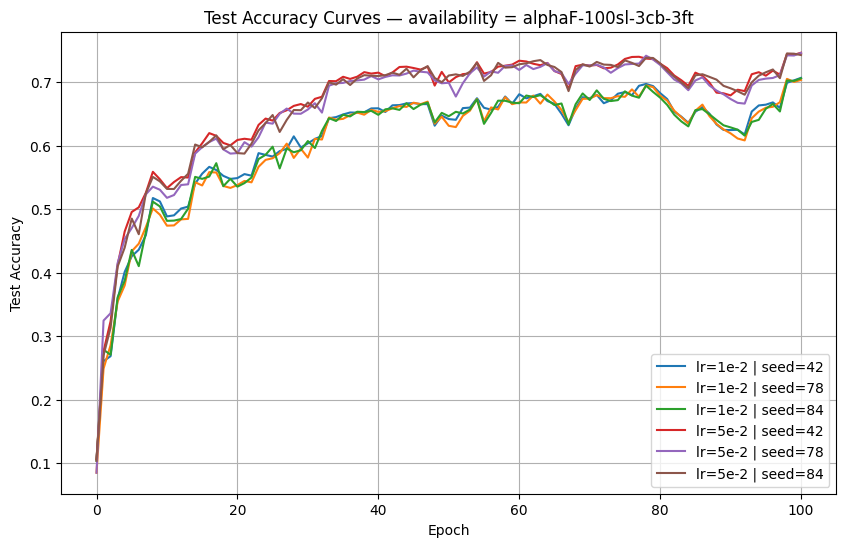

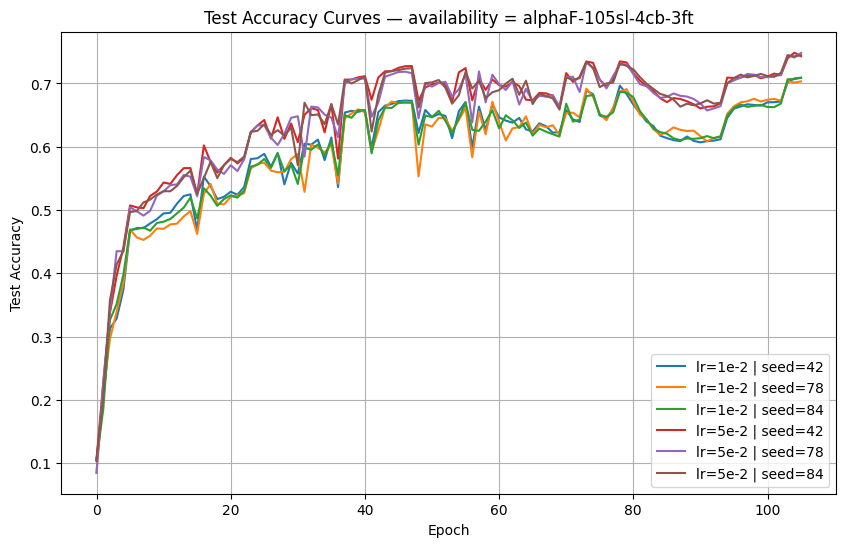

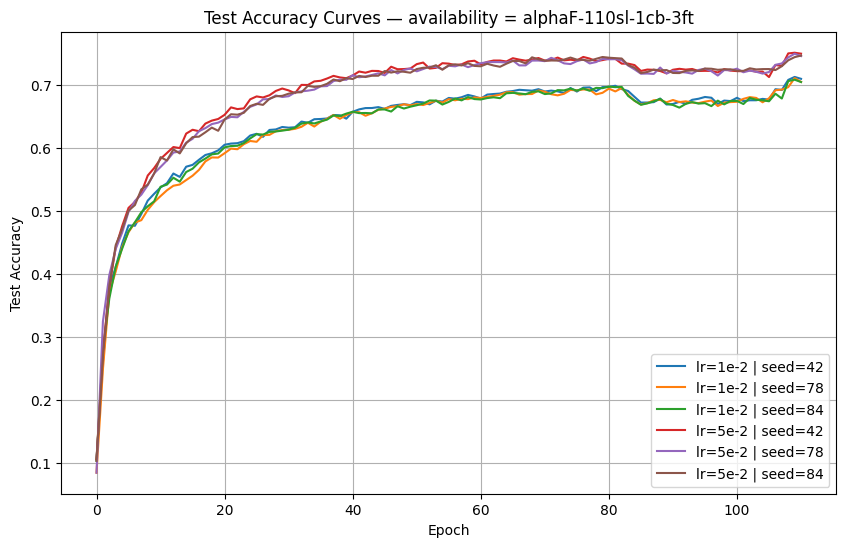

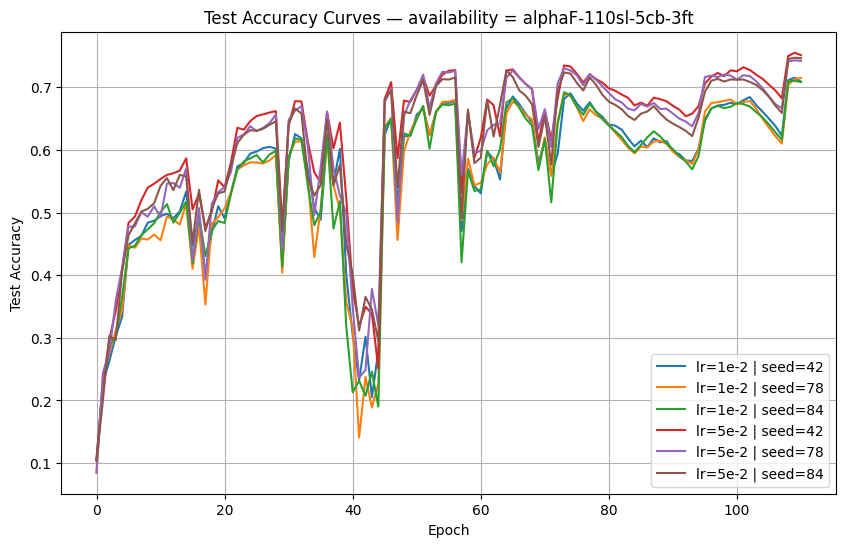

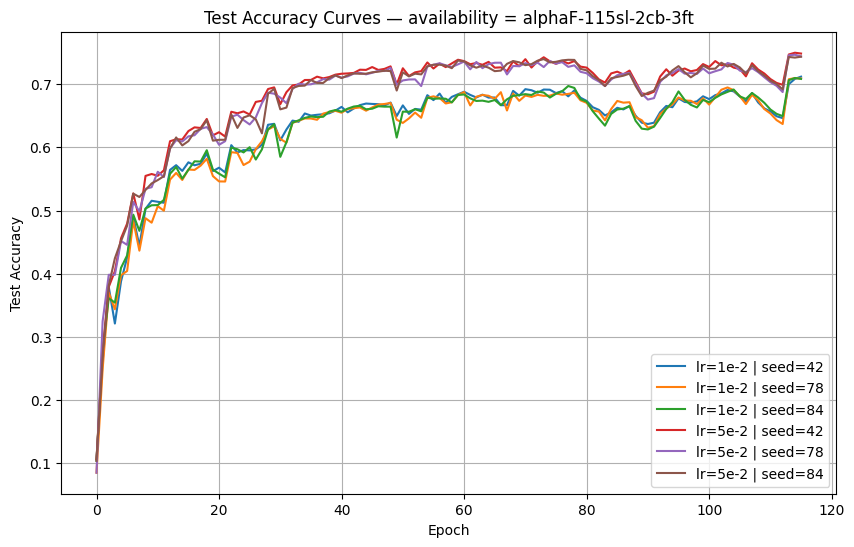

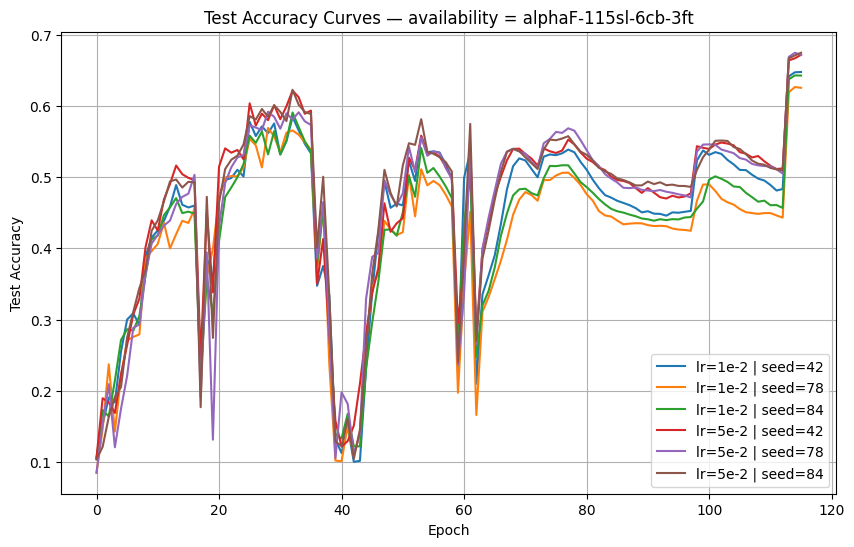

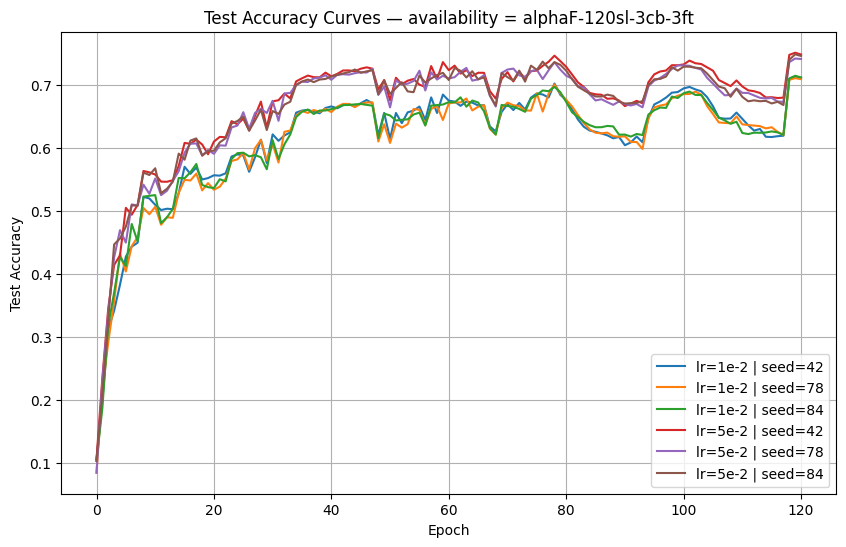

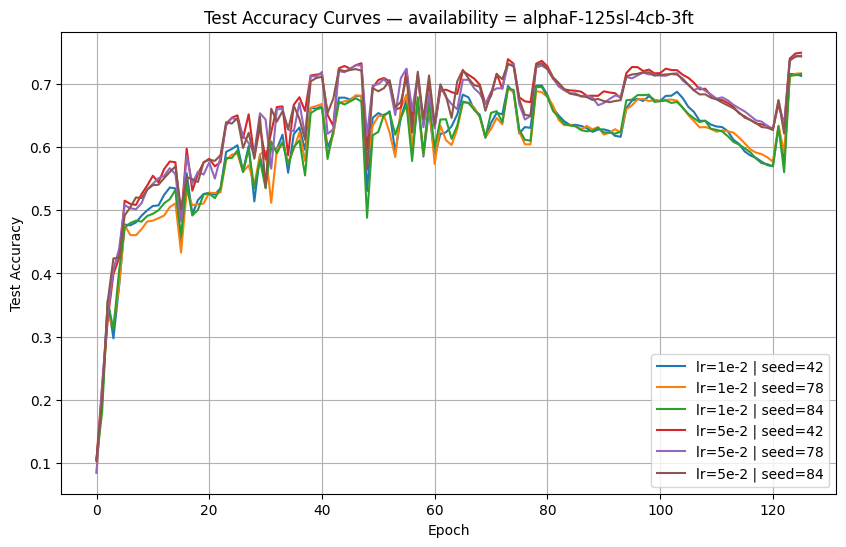

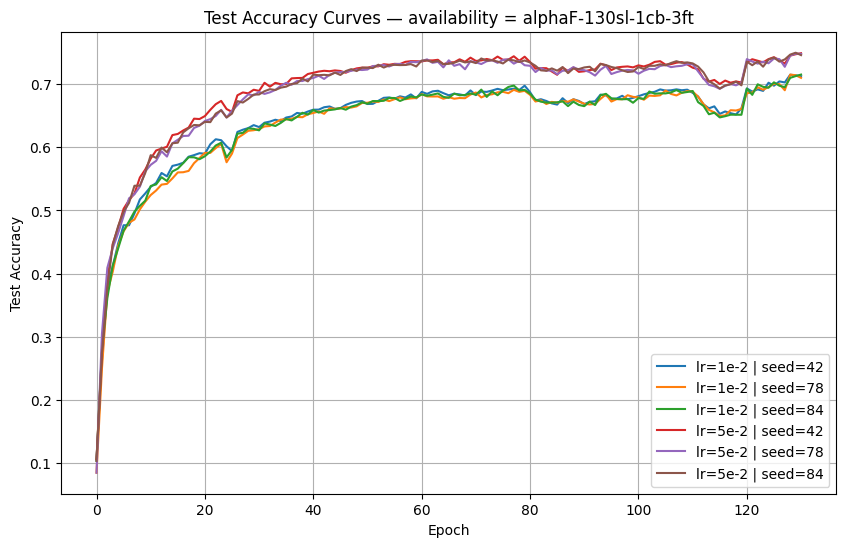

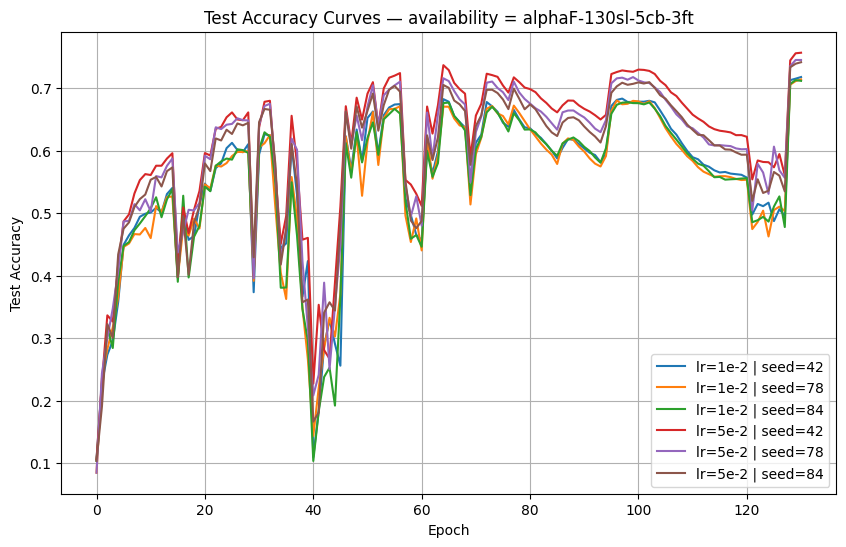

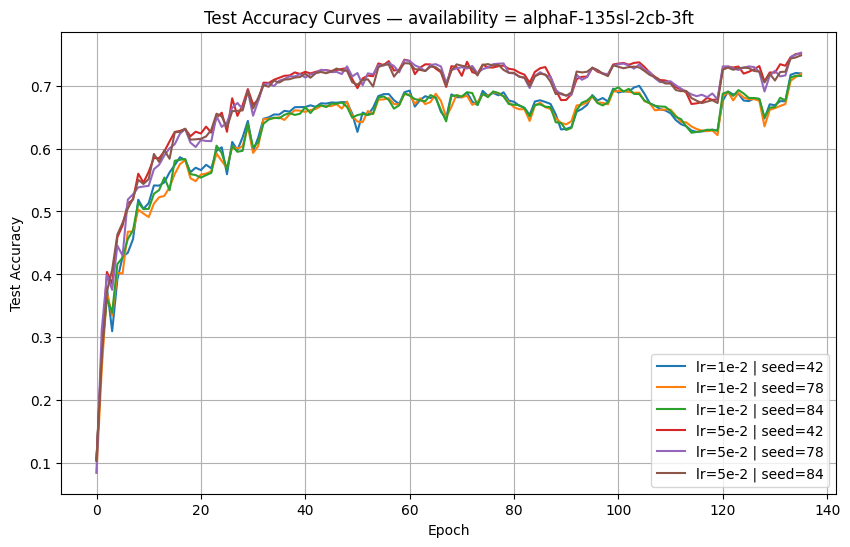

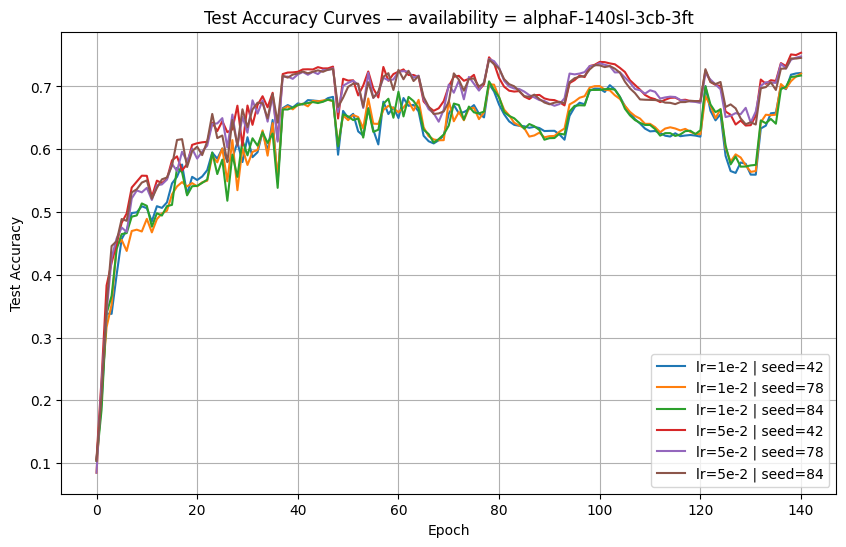

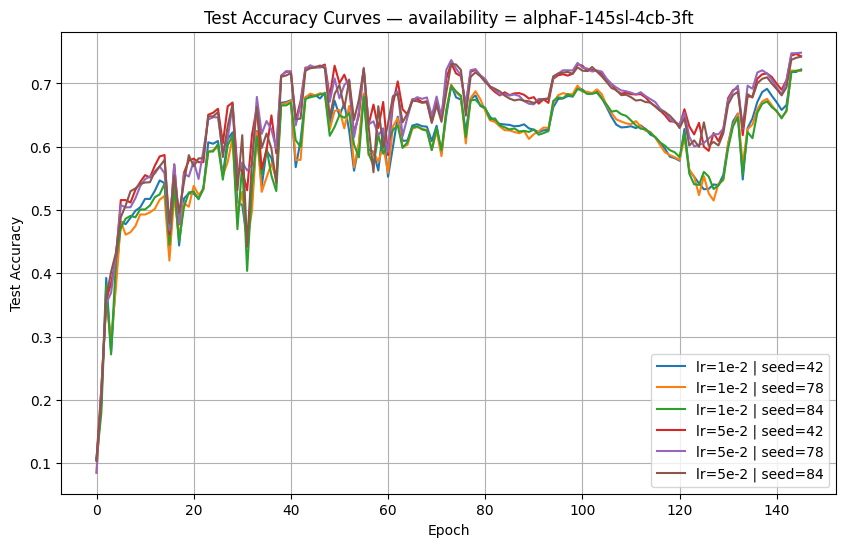

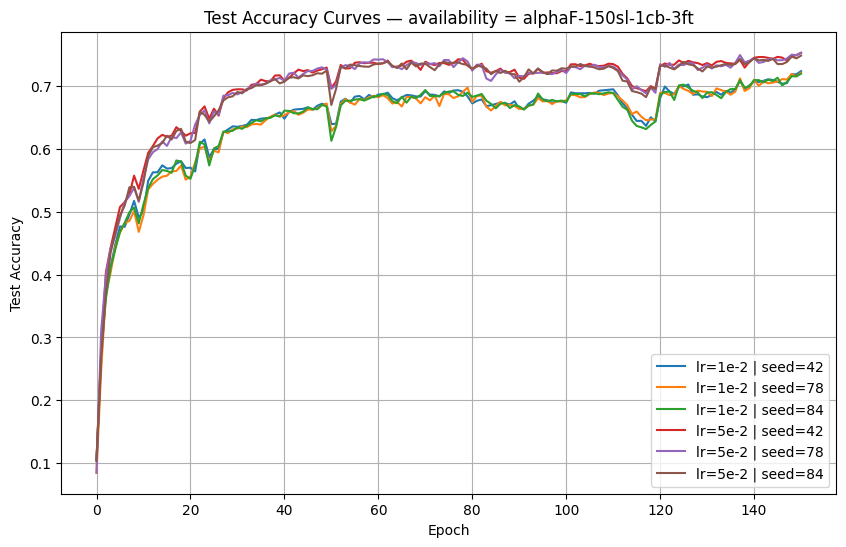

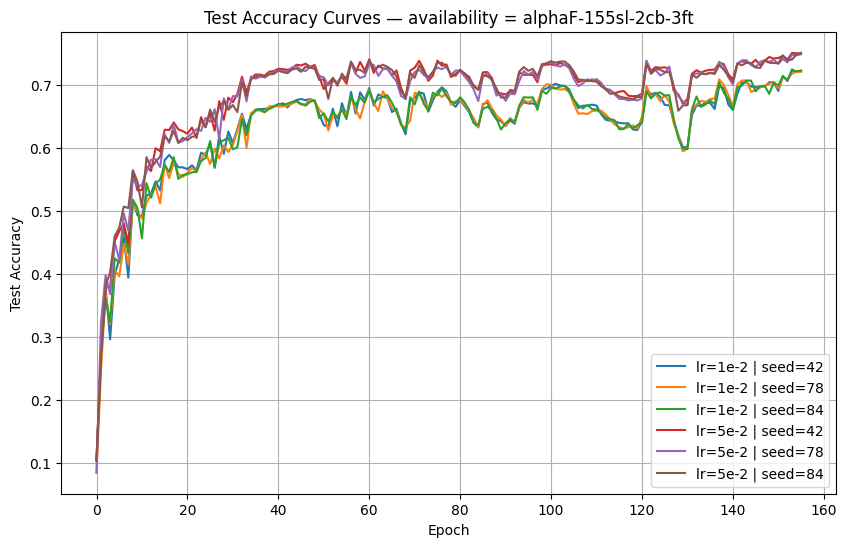

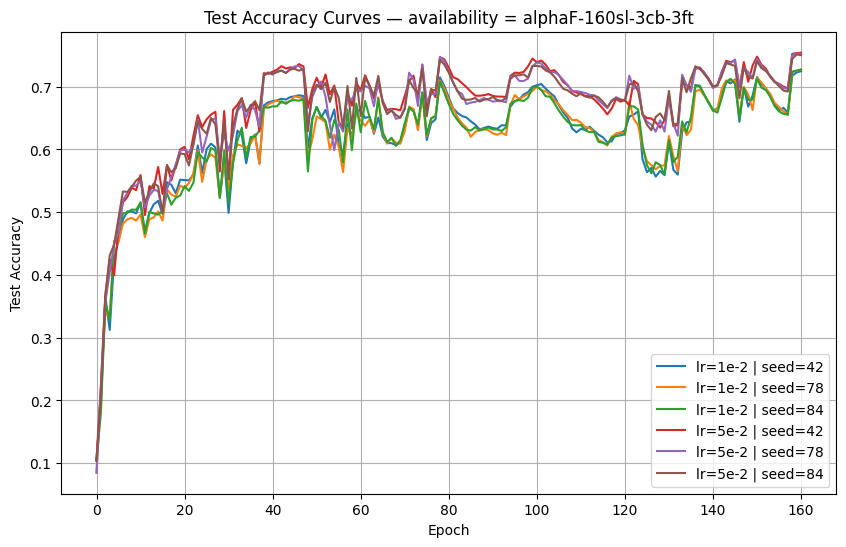

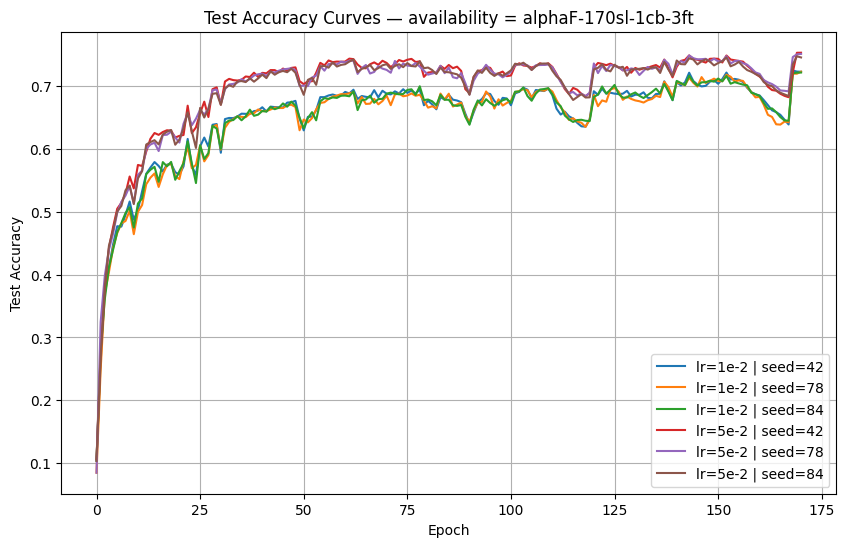

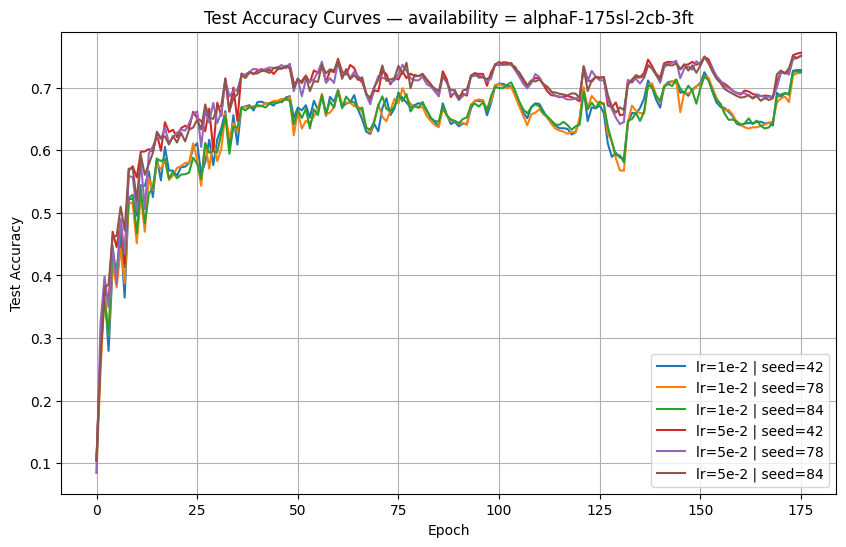

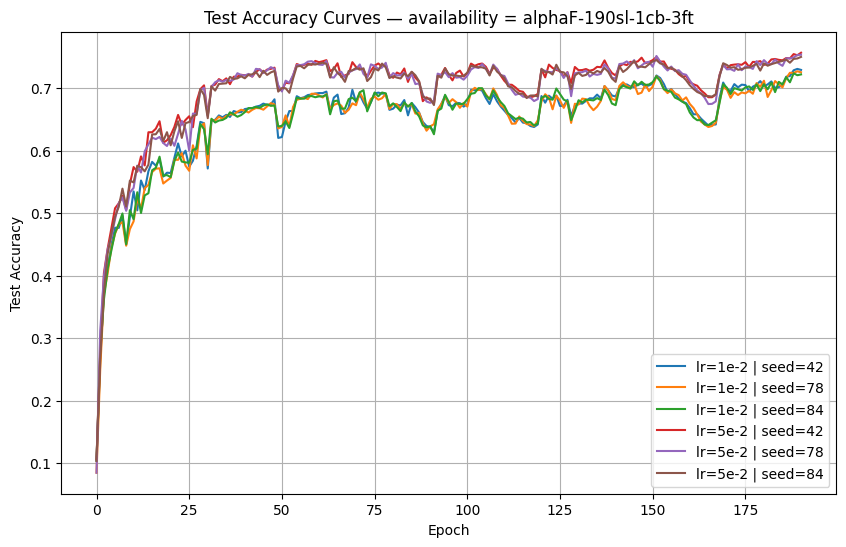

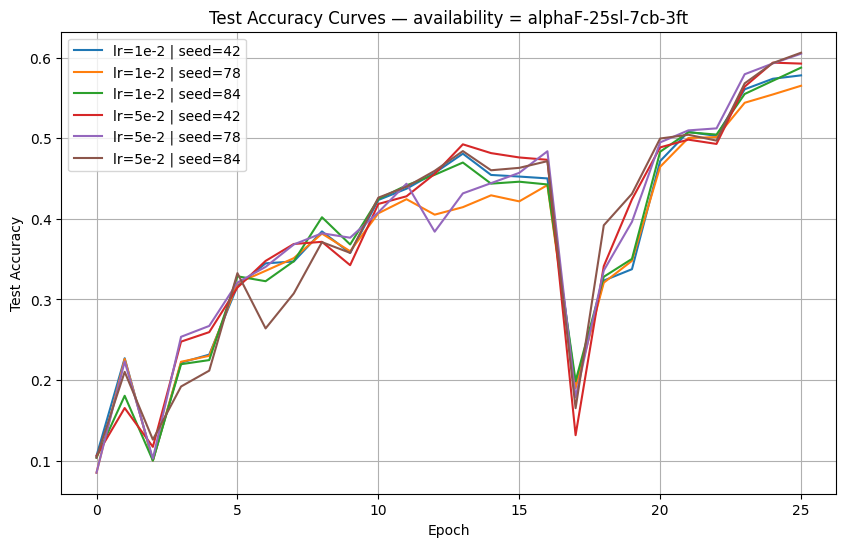

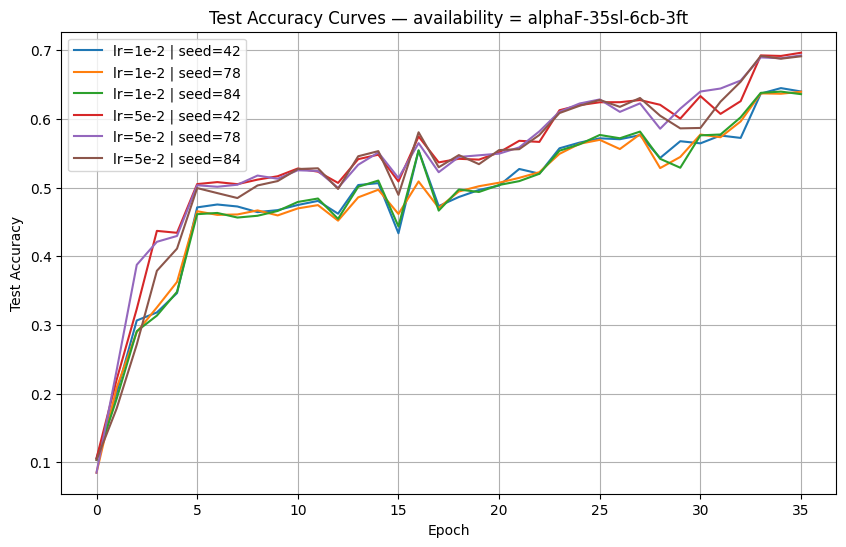

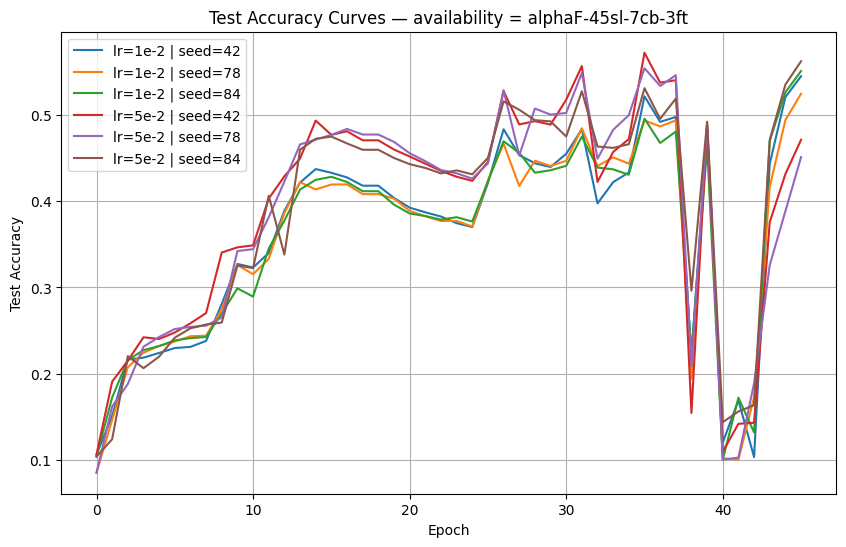

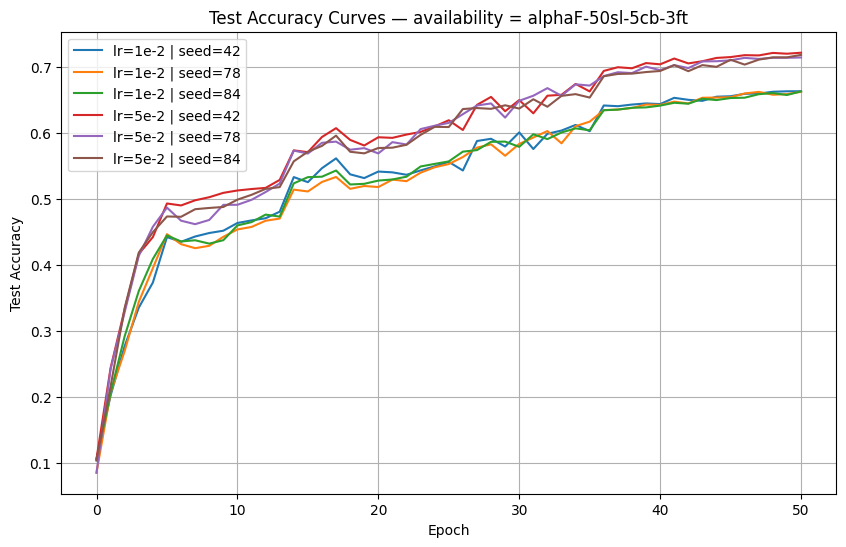

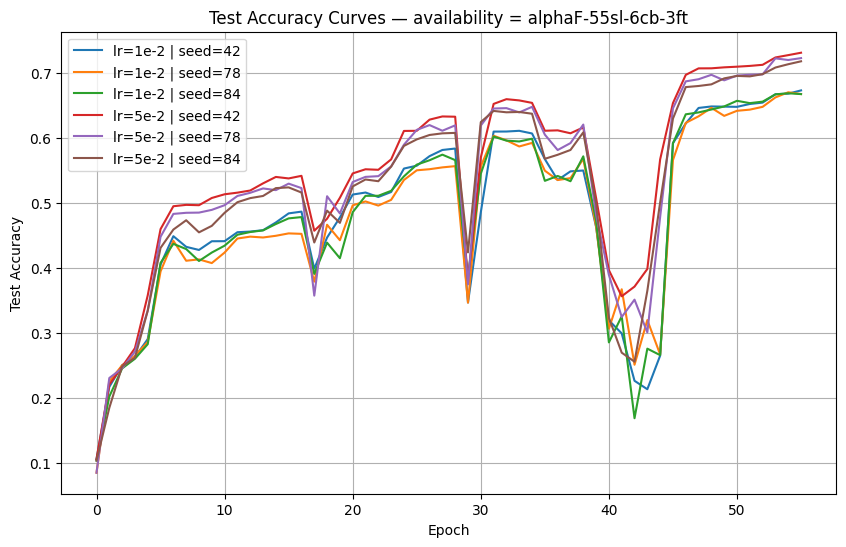

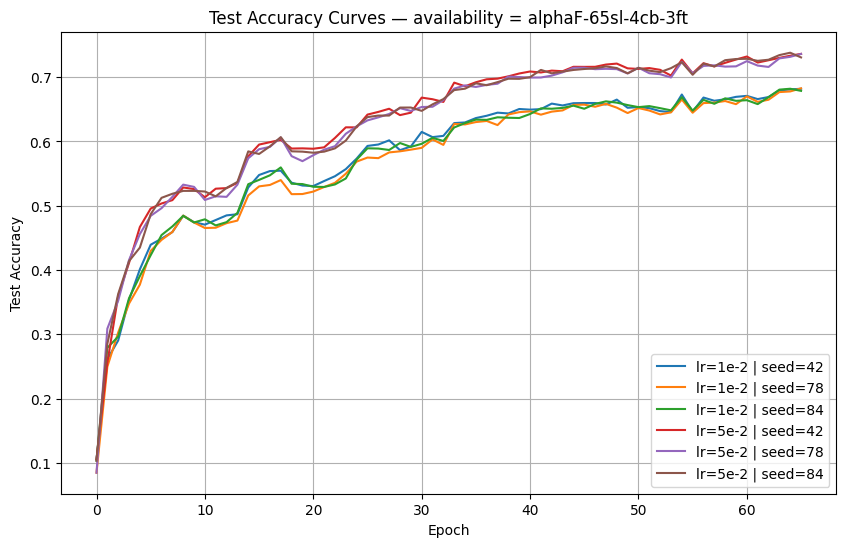

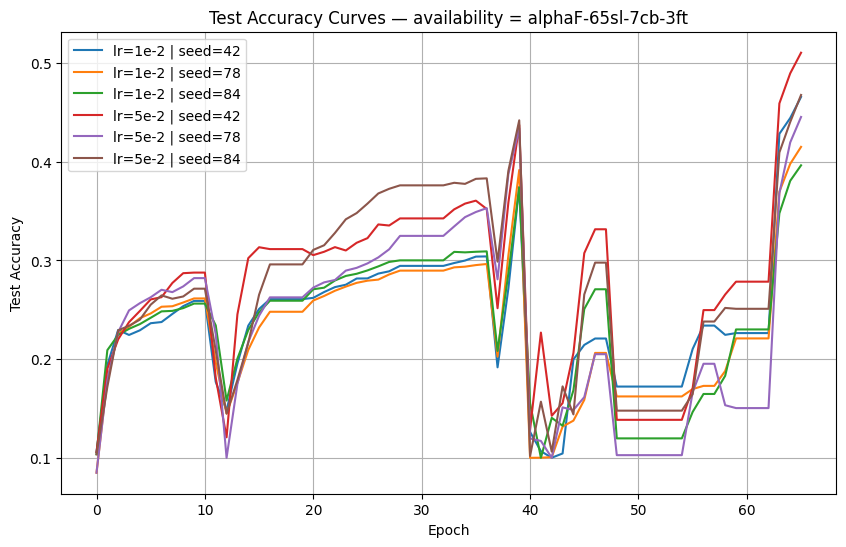

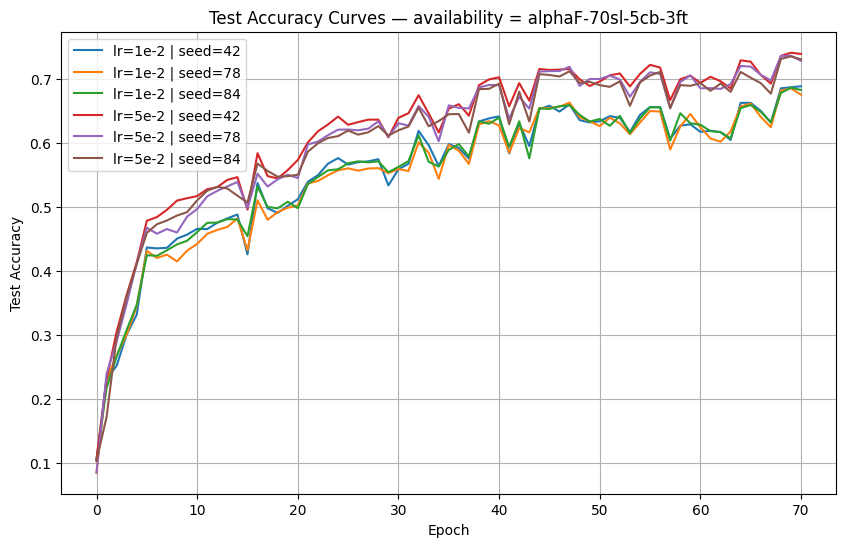

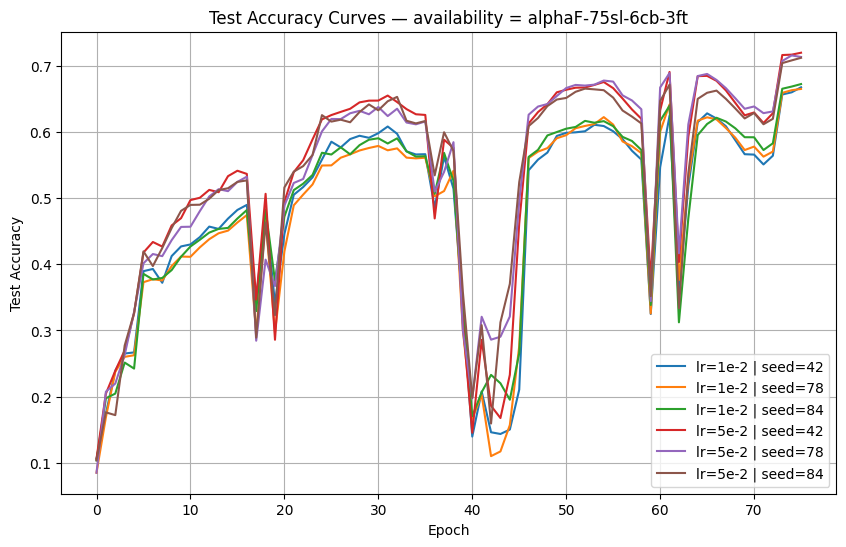

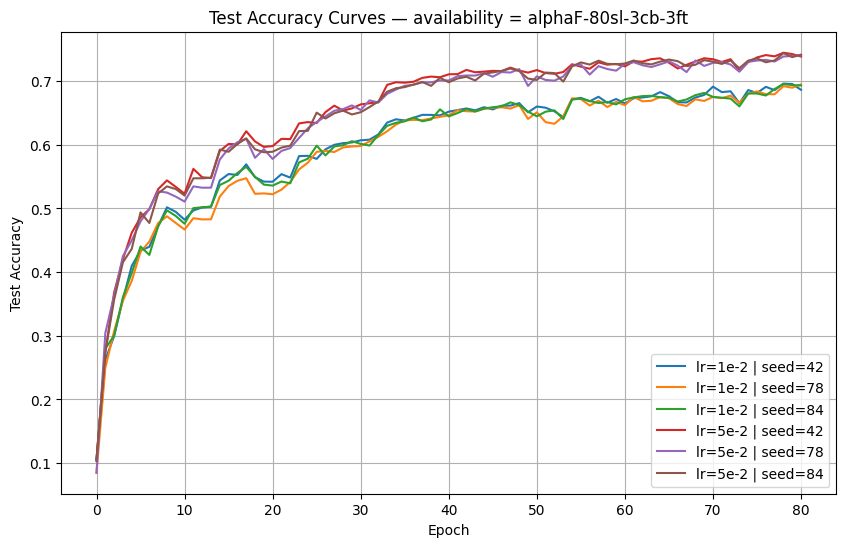

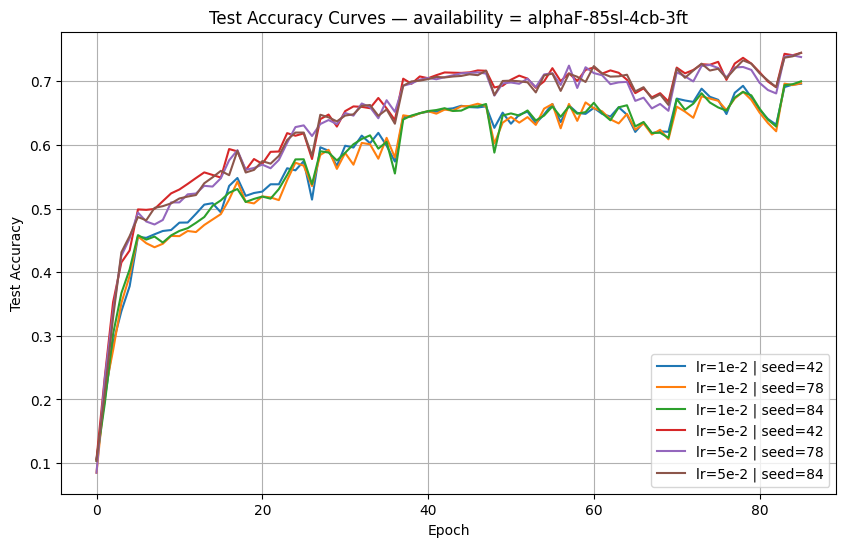

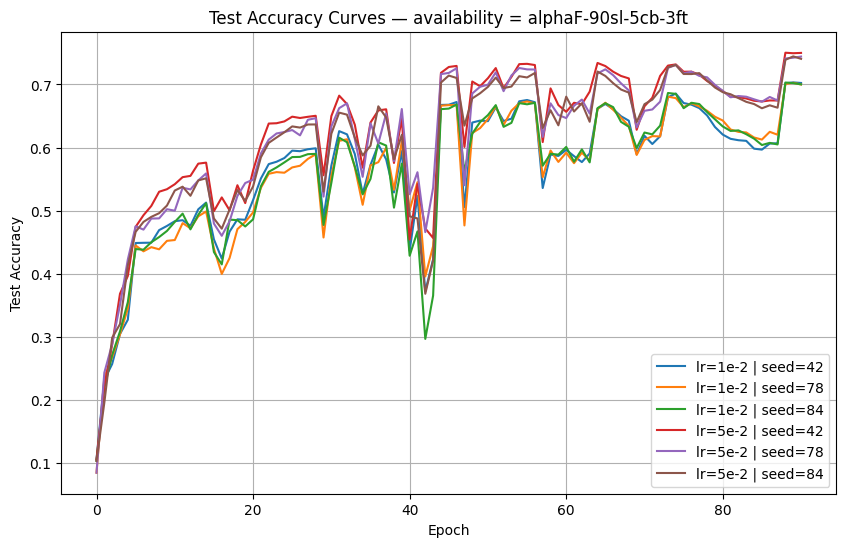

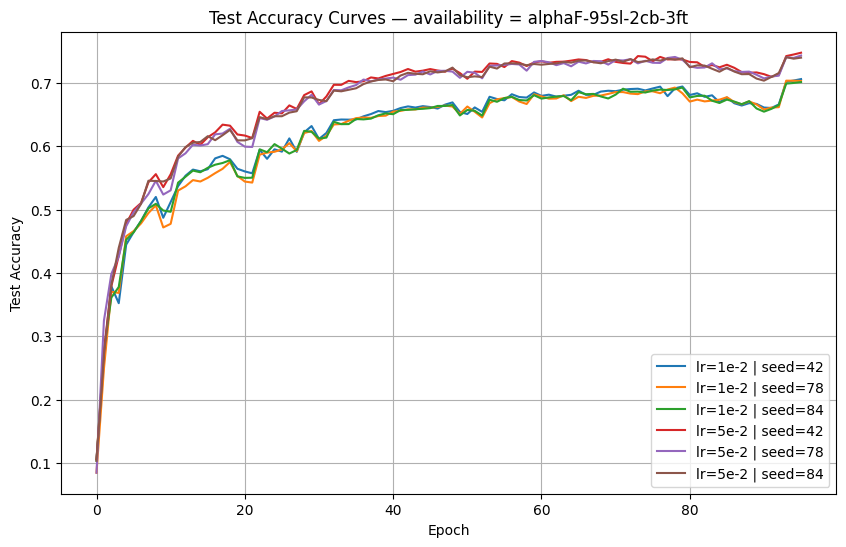

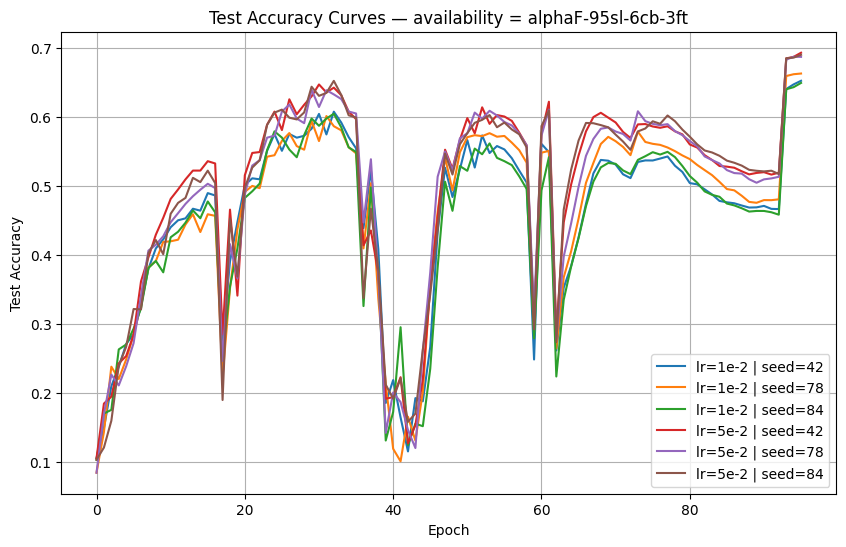

In [2]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from matplotlib import pyplot as plt
# from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

def parse_tf_events_file(events_path, tag, time_horizon=None):
    """
    Returns the data in the file located in the folder events_paths,
    and corresponding to the tag.
    The tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'.
    """
    ea = EventAccumulator(events_path).Reload()
    # print(list(ea.Scalars(tag)))
    tag_values, steps = [], []
    for event in ea.Scalars(tag):
        if time_horizon is None or event.step <= time_horizon:
            tag_values.append(event.value)
            steps.append(event.step)
    return steps, tag_values

def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for part in config.participations:
                                for biased in config.biased_list:
                                    for av in config.availabilities:
                                        print("Availability Matrix: ",av)
                                        try:
                                            event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                                event, a, n_c, av, 
                                                                                config.n_rounds, part, biased, config.train_test)
                                            # print('x')
                                            # print(event_dir)

                                            if os.path.exists(event_dir):
                                                
                                                # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                                _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                                # _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                                # _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                                # _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                                ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                                max_accuracy = np.array(test_accuracy_values).max() * 100
                                                results.append({
                                                    "algorithm": algorithm, 
                                                    "availability": av,
                                                    "alpha": a, 
                                                    "participation": part,
                                                    "max_test_accuracy": float(max_accuracy),
                                                    "final_test_accuracy":test_accuracy_values[-1]*100,
                                                    "test_accuracy": np.array(test_accuracy_values),
                                                    "seed": seed,
                                                    "lr": lr, "event": event, "n_clients": n_c,
                                                    "biased": biased
                                                })

                                                # "b": float(b) if b else np.nan # in case we vary beta
                                        except Exception as e:
                                            print(f"Failed: {e}")
    return pd.DataFrame(results)

main_folder = 'cifar10_accuracy_check'

availabilities="""
alphaF-25sl-7cb-3ft 
alphaF-35sl-6cb-3ft 
alphaF-45sl-7cb-3ft 
alphaF-50sl-5cb-3ft 
alphaF-55sl-6cb-3ft 
alphaF-65sl-4cb-3ft 
alphaF-65sl-7cb-3ft 
alphaF-70sl-5cb-3ft 
alphaF-75sl-6cb-3ft 
alphaF-80sl-3cb-3ft 
alphaF-85sl-4cb-3ft 
alphaF-90sl-5cb-3ft 
alphaF-95sl-2cb-3ft 
alphaF-95sl-6cb-3ft 
alphaF-100sl-3cb-3ft 
alphaF-105sl-4cb-3ft 
alphaF-110sl-1cb-3ft 
alphaF-110sl-5cb-3ft 
alphaF-115sl-2cb-3ft 
alphaF-115sl-6cb-3ft 
alphaF-125sl-4cb-3ft 
alphaF-130sl-1cb-3ft 
alphaF-130sl-5cb-3ft 
alphaF-135sl-2cb-3ft 
alphaF-145sl-4cb-3ft 
alphaF-150sl-1cb-3ft 
alphaF-155sl-2cb-3ft 
alphaF-170sl-1cb-3ft 
alphaF-175sl-2cb-3ft 
alphaF-120sl-3cb-3ft 
alphaF-140sl-3cb-3ft 
alphaF-160sl-3cb-3ft 
alphaF-190sl-1cb-3ft 
""".split()

config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10_group_notclip_v5", seeds=["42", "78", "84"],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['1e-2', '5e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities,
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")
results_df = get_exp_stats(config)

display(results_df)

import ast

# Convert 'test_accuracy' column to lists if needed
results_df['test_accuracy'] = results_df['test_accuracy'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Loop over availability groups
for availability_value, group in results_df.groupby("availability"):
    
    plt.figure(figsize=(10, 6))
    
    for _, row in group.iterrows():
        label = f"lr={row['lr']} | seed={row['seed']}"
        plt.plot(row['test_accuracy'], label=label)
    
    plt.title(f"Test Accuracy Curves — availability = {availability_value}")
    plt.xlabel("Epoch")
    plt.ylabel("Test Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

# config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10", seeds=["42", '78', '84'],
#                           algorithms=["fedavg"], events=["global"],
#                           lr_list=['5e-2','1e-2'], alphas=["0.1"], n_clients_list=["7"],
#                           availabilities=["alphaF-0cb-3ft"],
#                           n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

# results_df = load_experiment_results(config)
# # plot_availability_comparison_mean_seed(config, results_df, "test_accuracy", folder=main_folder+'/comp-av-mat/ft')